(sec:ode_solvers)=

# ODE Solvers

**O**rdinary **D**ifferential **E**quations (ODEs) are among the most important tools 
for modelling dynamical processes and arise across science, engineering, economics, 
and many other fields.
In chemistry, they are used for example in reaction kinetics, 
in transport and diffusion processes, and in the Schrödinger equation. 
In practice, one is often interested in an **I**nitial **V**alue **P**roblem (IVP),
in which the ODE is combined with an initial condition at a given time. 
As the simplest numerical method for such problems, we begin with the Euler method 
and use it to study the kinetics of a chemical reaction. 
We then introduce scipy.integrate.solve_ivp as a standard library routine 
for solving IVPs.

## Theoretical Foundations

We consider a first-order initial value problem of the form
:::{math}
:label: eq:ode-ivp
\frac{\mathrm{d}y}{\mathrm{d}t} = f(t, y), \qquad y(t_0) = y_0 \, .
:::

Our goal is to approximate the solution at discrete time points
$t_n = t_0 + n h$, where $h$ is the step size.

### Euler Method

The Euler method replaces the exact solution curve by a sequence of local
linear steps. Starting from $(t_n, y_n)$, we use the slope $f(t_n, y_n)$ to
predict the next value:
:::{math}
:label: eq:ode-euler
y_{n+1} = y_n + h f(t_n, y_n) \, .
:::

This formula is simple and easy to implement. Its main limitation is that the
accuracy depends strongly on the step size. If $h$ is too large, the numerical
solution may become inaccurate or even unstable.

```{tip} Derivation of the Euler Method
:class: dropdown
We start from the Taylor expansion of the exact solution around $t_n$:
:::{math}
:enumerated: false
y(t_n + h) = y(t_n) + h y'(t_n) + \mathcal{O}(h^2) \, .
:::
Using $y'(t_n) = f(t_n, y(t_n))$ (from the ODE, *cf.* Eq. {eq}`eq:ode-ivp`)
and neglecting the higher-order terms gives Eq. {eq}`eq:ode-euler`.
```

:::{note} Accuracy of the Euler Method
:class: dropdown
The neglected term is proportional to $h^2$, so the local error of one Euler
step is of order $h^2$. Over many steps, these errors accumulate, which is why
the global error is only of order $h$.
:::

## Implementation

We start again by importing Numpy.

In [1]:
import numpy as np

Is is common to deal with systems of first-order ODEs, which means that 
$y$ is a vector, and hence $f = y'$ is also a vector.
Therefore, we will use NumPy arrays to represent these quantities.

Before implementing the full method, it is helpful to separate a single 
Euler update into its own function. 

In [2]:
def euler_step(dydt, t_n, y_n, h):
    y_np1 = y_n + h * dydt(t_n, y_n)
    return y_np1

The function `euler_step` implements Eq. {eq}`eq:ode-euler` directly.
It takes the current time `t_n`, the current solution `y_n`, the step size `h`, 
and the function `dydt` that computes the derivative $f(t, y)$, 
and returns the next value `y_{n+1}`.

The complete Euler method now applies this step repeatedly on a uniform time
grid. The arguments are the initial time `t0`, the initial value `y0`, the
step size `h`, the derivative function `dydt`, and the number of time steps
`nsteps`. We return the time points and the corresponding solution values as arrays.

In [3]:
def euler_method(dydt, t0, y0, h, nsteps):
    ndim = len(y0)

    t_grid = t0 + np.arange(0, nsteps + 1) * h
    y_grid = np.zeros((ndim, nsteps + 1))
    y_grid[:, 0] = y0

    for i in range(nsteps):
        y_grid[:, i + 1] = euler_step(dydt, t_grid[i], y_grid[:, i], h)

    return t_grid, y_grid

The implementation has the same iterative structure as the algorithms from the
previous sections, but this time with a predetermined number of steps. Therefore,
a `for` loop is used.

The array `t_grid` contains all sampling times from `t0` to `t0 + nsteps * h`.
This is realised with the help of 
[`np.arange`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html),
which creates an array of equally spaced values. The last value is not included,
so we called this function with `nsteps + 1` as its second argument to ensure that 
the final time is included.
The object `y_grid` is now a two-dimensional array. Its first dimension stores
the components of the solution vector, and its second dimension stores the time
steps.

After setting the initial value with `y_grid[:, 0] = y0`, the loop moves
forward through the grid one point at a time. In every iteration, 
the function `euler_step` is called to compute the next value of the solution,
which is stored in `y_grid[:, i + 1]`. 

## Application

As an application, we consider the decay of tris(oxalato)manganate(III) ion, 
which is one of the experiments in the practical course in physical chemistry. 
We model the concentration $c(t)$ by the first-order initial value problem
:::{math}
:label: eq:ode-mn-decay
\frac{\mathrm{d}c}{\mathrm{d}t} = -k c(t), \qquad c(0) = c_0 \,.
:::
We use the fitted rate constant from experimental data and solve this IVP
numerically with the Euler method.

At first, we define the derivative function `dydt` according to the ODE. 
The function takes the current time `t` and the current concentration `c`, 
and returns the right-hand side of the Eq. {eq}`eq:ode-mn-decay`, which is $-k c$.
Because our implementation of the Euler method expects the solution to be a vector,
we represent the concentration as a one-dimensional array with one element,
and return the result as a one-dimensional array as well.


In [4]:
K_RATE = 0.0015803420

def dydt_mn(t, y):
    c = y[0]
    return np.array([-K_RATE * c])

In [5]:
C0 = np.array([1.0])

T0 = 0.0
STEP = 30.0
T_MAX = 1200.0

nsteps = int(T_MAX / STEP)
t_grid, y_euler = euler_method(dydt_mn, T0, C0, STEP, nsteps)
c_euler = y_euler[0]

print('number of steps:', nsteps)


number of steps: 40


For this model, the analytical solution is available,
:::{math}
:enumerated: false
c(t) = c_0 \exp(-k t) \, .
:::
This allows us to compare the numerical and analytical results directly.


In [6]:
c_exact = C0[0] * np.exp(-K_RATE * t_grid)

Now, we can plot the results to visually compare the Euler solution with the 
analytical solution.

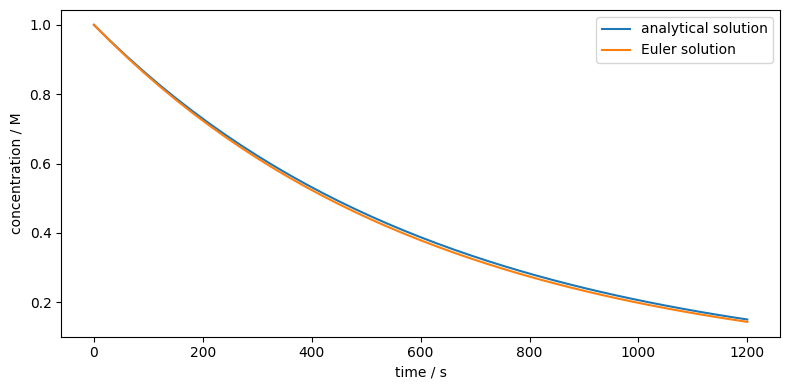

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, c_exact, label='analytical solution')
ax.plot(t_grid, c_euler, label='Euler solution')

ax.set_xlabel('time / s')
ax.set_ylabel('concentration / M')
ax.legend()
fig.tight_layout()

First, the Matplotlib library is imported.
Then, we create a figure and an axis object with 
[`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).
The size of the figure is set by the `figsize` argument to 
8 inches in width and 4 inches in height.
We then plot the analytical solution and the Euler solution on the same axis, 
using the `label` argument to specify the legend entries.
Afterwards, we set the labels for the x and y axes, 
add a legend using 
[`ax.legend()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html)
and adjust the layout of the figure using 
[`fig.tight_layout()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.tight_layout.html).

With the (deliberately) large step size $h = 30\,\mathrm{s}$, 
a difference between the Euler solution and the analytical curve can be visually observed. 

## Solving ODEs with SciPy

For practical work, it is often more convenient to use a library
implementation. SciPy provides the function
[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html),
which offers a common interface to several ODE solvers.

In the following, we use the `RK23` method, which is a more accurate solver 
based on the **R**unge-**K**utta family of methods.

In [8]:
from scipy.integrate import solve_ivp

res = solve_ivp(
    dydt_mn,
    t_span=(T0, T_MAX),
    y0=C0,
    t_eval=t_grid,
    method='RK23',
)

c_scipy = res.y[0]

print('function evaluations:', res.nfev)

function evaluations: 29


Here, we pass the same derivative function `dydt_mn` as before, but now we 
specify the time span as a tuple `(T0, T_MAX)`, instead of a fixed step size.
This is because `solve_ivp` uses an adaptive step size internally, which is adjusted automatically to meet a specified error tolerance. The time points at which the solution is evaluated are given by the `t_eval` argument, which allows us to obtain the solution at the same time points as in the Euler method for a direct comparison.

The return value `res` is an object with several useful attributes. In this
example, the most important ones are `res.y` for the numerical solution, 
and `res.nfev` for the number of function evaluations.
Since we passed the argument `t_eval`, the `res.t` attribute is the same as `t_grid`
and thus not very interesting in this case. Otherwise, `res.t` would contain 
the time points at which the solution was evaluated.

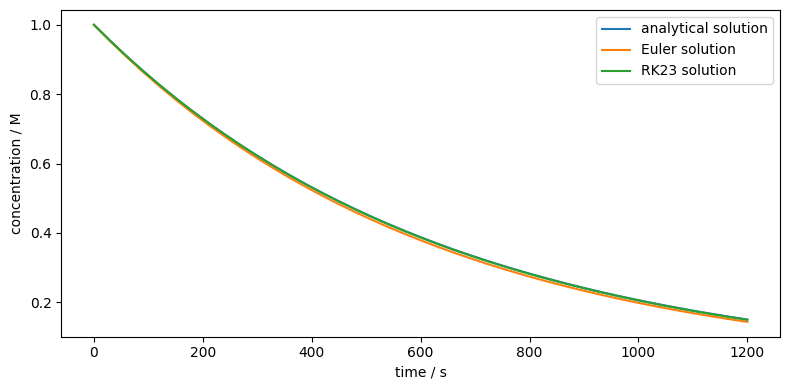

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, c_exact, label='analytical solution')
ax.plot(t_grid, c_euler, label='Euler solution')
ax.plot(t_grid, c_scipy, label='RK23 solution')

ax.set_xlabel('time / s')
ax.set_ylabel('concentration / M')
ax.legend()
fig.tight_layout()

Compared with the Euler method, the `RK23` method, albeit with a smaller amount
of function evaluations, is much closer to the analytical solution,
showing the advantage of using a more sophisticated solver.

:::{note} Selected Methods in `solve_ivp`
:class: dropdown

The function `solve_ivp` gives access to several ODE solvers. Some common
choices are:

- `RK23`: explicit Runge-Kutta method of lower order. Useful for simple
  problems or when a lower-order adaptive method is sufficient.
- `RK45`: explicit Runge-Kutta method of moderate order. A common default
  choice for many applications.
- `Radau`: implicit Runge-Kutta method. A good choice for
  [stiff](https://en.wikipedia.org/wiki/Stiff_equation) ODEs.
- `LSODA`: automatically switches between different strategies during the
  integration. This makes it a practical general-purpose method when the
  character of the problem is not known in advance.
:::

:::{note} Controlling Output and Step Size
:class: dropdown

The solver usually chooses its own internal step sizes automatically. The
argument `t_eval` specifies only the time points at which the solution should
be returned. If needed, `max_step` can be used to limit the largest internal
step size. Another useful option is `dense_output=True`, which constructs an
interpolating solution that can be evaluated afterwards like a function.
:::


:::{hint} Tip for Programming Style
Here we placed the import statements in the respective sections to emphasise 
the dependencies of the different parts of the script. The resulting code can be 
interpreted without errors. However, it is common in Python to place 
the imports at the beginning of the script, *i.e.*

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Rest of your code
```

## Self-Study Questions

1. Why does the Euler method need a step size `h`, and how does this choice
   affect the numerical result? Play around with different values of `h` and observe the changes in the solution.
2. In the implementation of `euler_method`, why is the initial value stored in
   `y_grid[:, 0]` before the loop starts?
3. Compare the roles of `t_eval` and `max_step` in `solve_ivp`. What is the
   difference between output points and internal solver steps?